# AttackPath AI: Identity & Agentic-Attack Detection Lab

> **Safety boundary:** This notebook uses deterministic synthetic telemetry only. It does not send phishing, collect credentials, exploit systems, or connect to a live environment.

## tl;dr

- The hybrid rule + logistic model reaches **100.0% precision**, **90.2% recall**, and **94.8% F1** on a stable held-out event split.
- Attack chains are detected in **4.0 minutes on average** from their first simulated event.
- **100.0% of chains** are detected before the synthetic exfiltration stage.
- These values prove that the demo is reproducible; they do not estimate production performance.


## Context & Methods

The lab combines transparent security rules with a small logistic classifier. It evaluates three current defensive scenarios: device-code phishing, an infostealer-to-cloud pivot, and prompt-injection-driven tool abuse.

### Key Assumptions

- Every identity, asset, event, score, and attack chain is fictional.
- Labels are known because this is a controlled simulation.
- A real deployment would require privacy review, source-specific calibration, time-based validation, and human approval for containment.


## Data

### 1. Load the deterministic telemetry and project helpers

In [1]:
import json
import sys
from pathlib import Path

project_root = Path.cwd() / "attackpath-ai"
if not project_root.exists():
    project_root = Path.cwd()
sys.path.insert(0, str(project_root))

from attackpath_ai.core import DEFAULT_THRESHOLD, SCENARIO_LABELS, analyze_events, generate_synthetic_events
from attackpath_ai.visuals import attack_path_svg, confusion_matrix_svg, risk_distribution_svg

class SVGFigure:
    def __init__(self, svg):
        self.svg = svg
    def _repr_svg_(self):
        return self.svg
    def __repr__(self):
        return "<AttackPath SVG figure>"

events = generate_synthetic_events()
analysis = analyze_events(events)
results = analysis["results"]
print(f"Loaded {len(events):,} deterministic synthetic events.")
print(json.dumps(analysis["counts"], indent=2))


Loaded 936 deterministic synthetic events.
{
  "events": 936,
  "attack_events": 216,
  "benign_events": 720,
  "alerts": 200,
  "high_or_critical_alerts": 153,
  "attack_paths": 36
}


### 2. Inspect a bounded sample

In [2]:
sample_columns = ("timestamp", "scenario", "stage", "source", "identity", "asset", "action")
print(" | ".join(sample_columns))
print("-" * 132)
for event in events[:8]:
    row = event.__dict__
    print(" | ".join(str(row[column])[:22] for column in sample_columns))


timestamp | scenario | stage | source | identity | asset | action
------------------------------------------------------------------------------------------------------------------------------------
2026-06-01T08:00:00Z | normal_activity | Benign | AI Agent | user-001 | support-agent | agent_summarize_ticket
2026-06-01T08:08:00Z | normal_activity | Benign | SaaS | user-002 | document-store | read_project_document
2026-06-01T08:15:00Z | normal_activity | Benign | Identity | user-003 | workforce-sso | interactive_login
2026-06-01T08:21:00Z | normal_activity | Benign | AI Agent | user-004 | support-agent | agent_summarize_ticket
2026-06-01T08:28:00Z | normal_activity | Benign | Cloud | user-005 | analytics-warehouse | run_approved_query
2026-06-01T08:37:00Z | normal_activity | Benign | SaaS | user-006 | document-store | read_project_document
2026-06-01T08:46:00Z | normal_activity | Benign | GitHub | user-007 | engineering-repo | list_assigned_issues
2026-06-01T08:51:00Z | normal_activity 

## Results

### 3. Measure held-out event detection

The test split is stable and derived from hashed synthetic event IDs. Precision measures alert quality; recall measures simulated attack-event coverage; F1 balances both.


In [3]:
metrics = analysis["test_metrics"]
operations = analysis["operational_metrics"]
print(json.dumps({"held_out": metrics, "attack_paths": operations}, indent=2))
assert metrics["precision"] >= 0.85
assert metrics["recall"] >= 0.90
assert operations["path_prevention_rate"] >= 0.90


{
  "held_out": {
    "tp": 55,
    "fp": 0,
    "tn": 228,
    "fn": 6,
    "precision": 1.0,
    "recall": 0.9016393442622951,
    "f1": 0.9482758620689655,
    "accuracy": 0.9792387543252595
  },
  "attack_paths": {
    "mean_minutes_to_detect": 4.0,
    "median_minutes_to_detect": 0.0,
    "paths_prevented_before_exfiltration": 36,
    "path_prevention_rate": 1.0
  }
}


### 4. Compare benign and simulated-attack risk scores

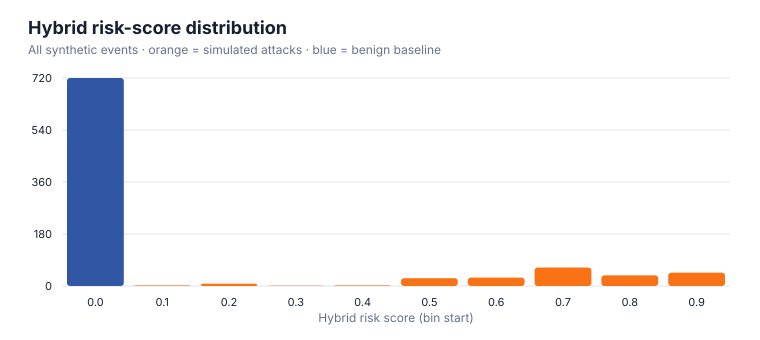

In [4]:
SVGFigure(risk_distribution_svg(results))

The score distribution is intentionally separated because the fixture makes attack behaviors observable. Production data will overlap more and must be recalibrated against real analyst decisions.

### 5. Follow one attack from entry to exfiltration


Chain: prom-00 | first detection: Execution | MTTD: 11.0 minutes


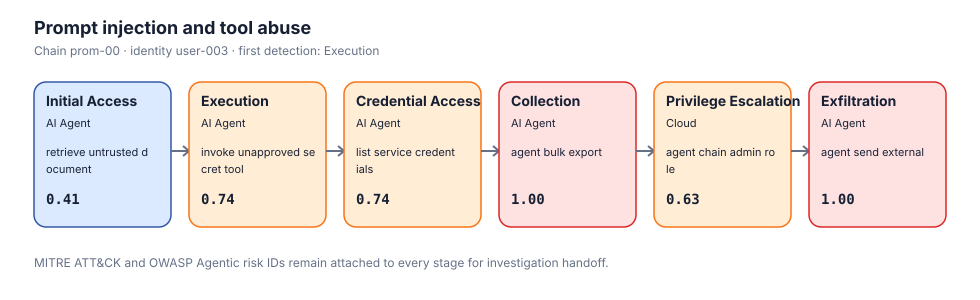

In [5]:
selected_path = next(path for path in analysis["paths"] if path["scenario"] == "prompt_injection_tool_abuse")
print(f"Chain: {selected_path['chain_id']} | first detection: {selected_path['detected_stage']} | MTTD: {selected_path['minutes_to_detect']:.1f} minutes")
SVGFigure(attack_path_svg(selected_path))


### 6. Inspect the error types

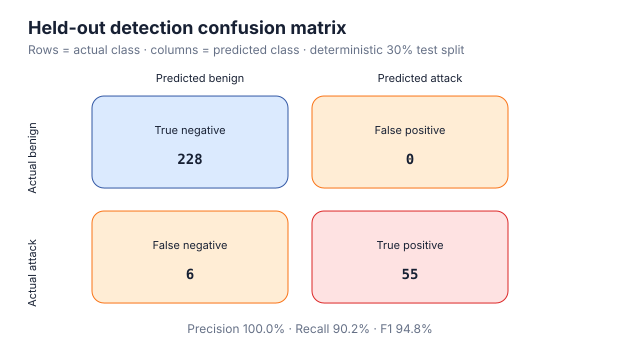

In [6]:
SVGFigure(confusion_matrix_svg(metrics))

### 7. Review global model influence and the highest-risk alerts

In [7]:
print("Global feature influence (absolute standardized weights)")
for item in analysis["feature_importance"]:
    print(f"  {item['feature']:>18}: {item['absolute_weight']:.3f}")

print("\nHighest-risk synthetic events")
for alert in analysis["top_alerts"][:8]:
    print(f"  {alert['hybrid_score']:.3f} | {alert['severity']:<8} | {alert['identity']} | {alert['stage']:<20} | {', '.join(alert['rule_hits'])}")


Global feature influence (absolute standardized weights)
           tool_risk: 1.565
         device_risk: 1.446
          rule_score: 0.703
           token_age: 0.499
            weak_mfa: 0.471
    unusual_location: 0.417
         data_volume: 0.316
           privilege: 0.261

Highest-risk synthetic events
  1.000 | Critical | user-005 | Exfiltration         | untrusted foreign session, weak-MFA token replay, privilege escalation, bulk data movement, probable exfiltration
  1.000 | Critical | user-002 | Exfiltration         | untrusted foreign session, weak-MFA token replay, privilege escalation, bulk data movement, probable exfiltration
  1.000 | Critical | user-008 | Exfiltration         | untrusted foreign session, weak-MFA token replay, privilege escalation, bulk data movement, probable exfiltration
  1.000 | Critical | user-004 | Exfiltration         | untrusted foreign session, weak-MFA token replay, privilege escalation, bulk data movement, probable exfiltration
  1.000 | Cr

## Takeaways

1. **Identity is the connective tissue.** The most useful detections correlate authentication, endpoint, GitHub, cloud, SaaS, and agent actions instead of treating each source in isolation.
2. **Agent actions need identity controls.** Prompt injection becomes materially dangerous when an agent holds broad tool permissions or can chain into privileged cloud roles.
3. **Event accuracy is not enough.** The project reports time-to-detect and whether a chain is found before exfiltration, which are closer to SOC outcomes.
4. **Rules and ML play different roles.** Rules give analysts explicit reasons; the model provides a second behavioral signal. Neither performs autonomous containment.

## Next Steps

- Replace the fixture with privacy-reviewed, authorized logs and time-based validation.
- Calibrate thresholds by analyst capacity and cost of false negatives.
- Add phishing-resistant MFA, short-lived workload identity, just-in-time privilege, and agent tool approvals as measurable controls.
- Track drift, missing telemetry, and subgroup performance before any production use.


## Checks

### 8. Run reproducibility and safety release gates

In [8]:
assert events == generate_synthetic_events(), "generator must be deterministic"
assert len({event.event_id for event in events}) == len(events), "event IDs must be unique"
assert all("@" not in event.identity for event in events), "fixture must not contain email identities"
assert all(path["event_count"] == 6 for path in analysis["paths"]), "every attack path should have six stages"
assert all(path["prevented_before_exfiltration"] for path in analysis["paths"]), "every fixture path should be detected before exfiltration"
print("PASS: deterministic data, unique IDs, synthetic identities, complete paths, and pre-exfiltration detection")


PASS: deterministic data, unique IDs, synthetic identities, complete paths, and pre-exfiltration detection
